In [2]:
import os
import sys
import warnings
from pathlib import Path
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (16, 12)


In [ ]:
# CHANGE ONLY THIS CELL IF SESSION CHANGES
# Use a session from the new split:
# Train: 303, 304, 305, 310, 312, 313, 315, 316, 317
# Test: 300, 301
session_path = Path(
    r"data\303"  # Example: change to 300 for test session
)

session_id = session_path.name

data = {}
features = {}

if not session_path.exists():
    raise FileNotFoundError(f"Session path does not exist: {session_path}")

print("Session:", session_id)
print("Path:", session_path)


Session: 302
Path: data\302


In [13]:
transcript_file = session_path / f"{session_id}_TRANSCRIPT.csv"

if transcript_file.exists():
    try:
        try:
            df_transcript = pd.read_csv(transcript_file, sep="\t")
        except:
            df_transcript = pd.read_csv(transcript_file)

        data["transcript"] = df_transcript

        print("✓ Transcript loaded")
        print("Utterances:", len(df_transcript))
        print("Columns:", list(df_transcript.columns))

        print("\nSample rows:")
        display(df_transcript.head(2))

    except Exception as e:
        print("Transcript read error:", e)
else:
    print("Transcript file not found")


✓ Transcript loaded
Utterances: 186
Columns: ['start_time', 'stop_time', 'speaker', 'value']

Sample rows:


,start_time,stop_time,speaker,value
0,35.18,37.99,Ellie,hi i'm ellie thanks for coming in today
1,38.59,41.72,Ellie,i was created to talk to people in a safe and ...


In [15]:
features_2d = session_path / f"{session_id}_CLNF_features.txt"
features_3d = session_path / f"{session_id}_CLNF_features3D.txt"

print("FACIAL FEATURES")

if features_2d.exists():
    df_facial_2d = pd.read_csv(features_2d, sep=", ", engine="python")
    features["facial_2d"] = df_facial_2d

    print("✓ 2D landmarks")
    print("Frames:", len(df_facial_2d))
    print("Avg confidence:", df_facial_2d["confidence"].mean())

if features_3d.exists():
    df_facial_3d = pd.read_csv(features_3d, sep=", ", engine="python")
    features["facial_3d"] = df_facial_3d

    print("✓ 3D landmarks")
    print("Frames:", len(df_facial_3d))


FACIAL FEATURES
✓ 2D landmarks
Frames: 31012
Avg confidence: 0.9314653674380885
✓ 3D landmarks
Frames: 31012


In [17]:
gaze_file = session_path / f"{session_id}_CLNF_gaze.txt"

if gaze_file.exists():
    df_gaze = pd.read_csv(gaze_file, sep=", ", engine="python")
    features["gaze"] = df_gaze

    print("✓ Gaze data")
    print("Frames:", len(df_gaze))
else:
    print("Gaze file not found")


✓ Gaze data
Frames: 31012


In [18]:
au_file = session_path / f"{session_id}_CLNF_AUs.csv"

if au_file.exists():
    df_au = pd.read_csv(au_file)
    features["action_units"] = df_au

    au_binary = [c for c in df_au.columns if "_c" in c]
    au_reg = [c for c in df_au.columns if "_r" in c]

    print("✓ Action Units loaded")
    print("Frames:", len(df_au))
    print("Binary AUs:", len(au_binary))
    print("Regression AUs:", len(au_reg))
else:
    print("AU file not found")


AU file not found


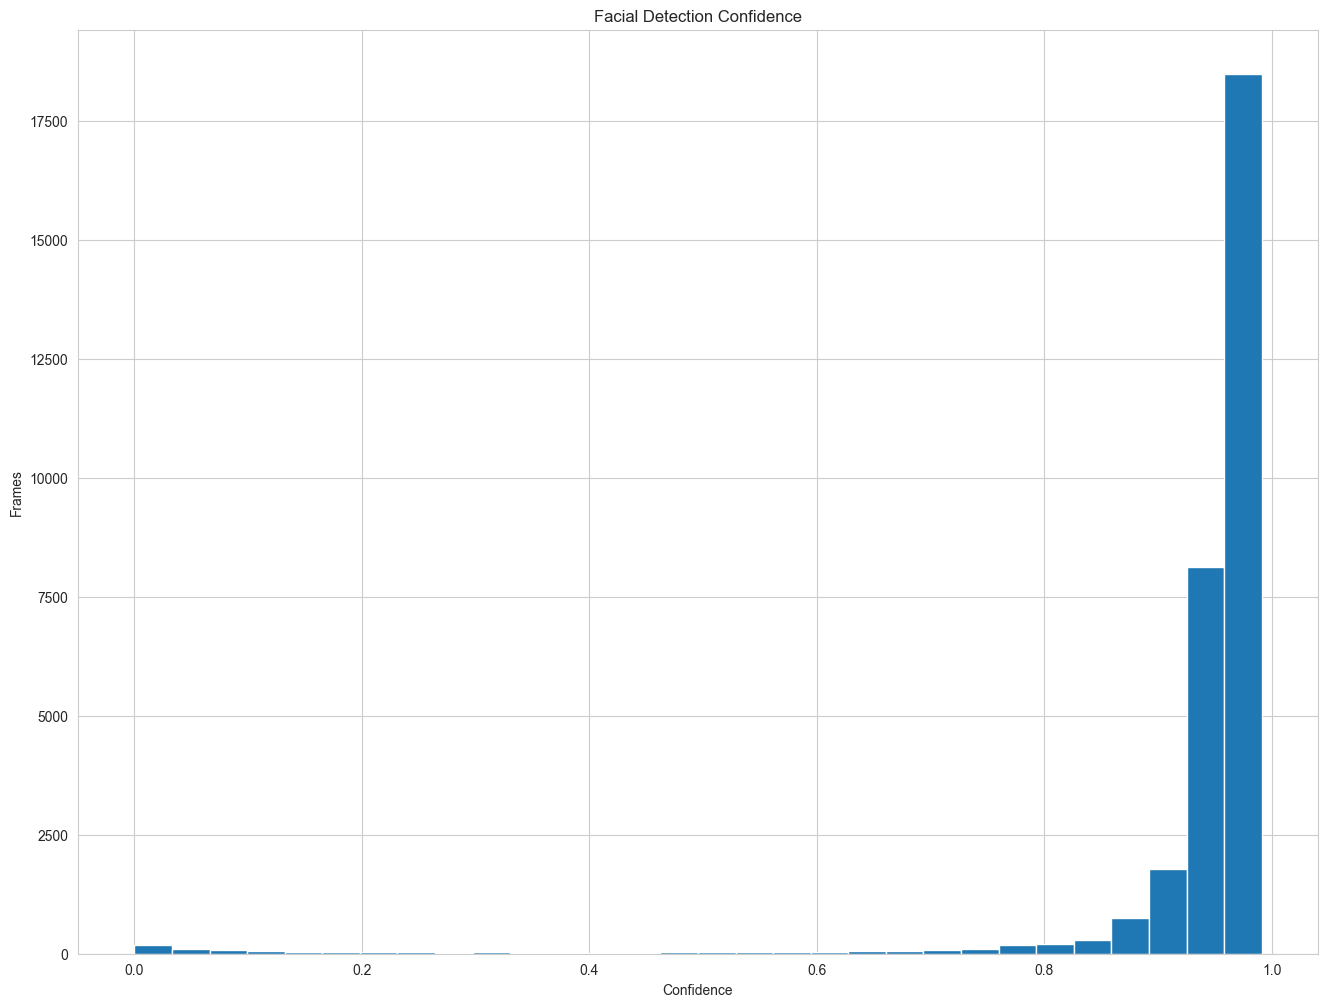

In [19]:
if "facial_2d" in features:
    plt.hist(features["facial_2d"]["confidence"], bins=30)
    plt.title("Facial Detection Confidence")
    plt.xlabel("Confidence")
    plt.ylabel("Frames")
    plt.show()

if "action_units" in features:
    au_cols = [c for c in features["action_units"].columns if "_c" in c][:8]
    sns.heatmap(
        features["action_units"][au_cols].iloc[:100].T,
        cmap="RdYlGn",
        cbar=False
    )
    plt.title("AU Activation (first 100 frames)")
    plt.show()


In [20]:
print(df_pose.columns.tolist())


['frame', 'timestamp', 'confidence', 'success', 'Tx', 'Ty', 'Tz', 'Rx', 'Ry', 'Rz']


In [21]:
# ==============================
# HEAD POSE ANALYSIS CELL
# ==============================

import numpy as np
import pandas as pd

# ---- 1. Basic validation ----
print("Initial frames:", len(df_pose))
print("Columns:", df_pose.columns.tolist())

# ---- 2. Filter invalid head-pose frames ----
df_pose = df_pose[df_pose["success"] == 1]
df_pose = df_pose[df_pose["confidence"] >= 0.7]

print("Valid frames after filtering:", len(df_pose))

# ---- 3. Sort by frame (important for temporal logic) ----
df_pose = df_pose.sort_values("frame").reset_index(drop=True)

# ---- 4. Sanity check: rotation ranges ----
print("\nRotation ranges (degrees):")
print("Rx (Pitch):", df_pose["Rx"].min(), "→", df_pose["Rx"].max())
print("Ry (Yaw):  ", df_pose["Ry"].min(), "→", df_pose["Ry"].max())
print("Rz (Roll): ", df_pose["Rz"].min(), "→", df_pose["Rz"].max())

# ---- 5. Smooth rotations (reduces jitter) ----
window = 5  # small window for real-time stability

df_pose["Rx_smooth"] = df_pose["Rx"].rolling(window, center=True).mean()
df_pose["Ry_smooth"] = df_pose["Ry"].rolling(window, center=True).mean()
df_pose["Rz_smooth"] = df_pose["Rz"].rolling(window, center=True).mean()

# Fill NaNs created by rolling
df_pose[["Rx_smooth","Ry_smooth","Rz_smooth"]] = (
    df_pose[["Rx_smooth","Ry_smooth","Rz_smooth"]]
    .fillna(method="bfill")
    .fillna(method="ffill")
)

# ---- 6. Attention / looking-away logic ----
# Thresholds are human-realistic and widely used

YAW_THRESHOLD = 25    # degrees
PITCH_THRESHOLD = 20 # degrees

df_pose["looking_away"] = (
    (df_pose["Ry_smooth"].abs() > YAW_THRESHOLD) |
    (df_pose["Rx_smooth"].abs() > PITCH_THRESHOLD)
)

# ---- 7. Gesture detection (optional but useful) ----
df_pose["nod"] = df_pose["Rx_smooth"].diff().abs() > 8
df_pose["shake"] = df_pose["Ry_smooth"].diff().abs() > 10

# ---- 8. Summary statistics ----
print("\nHead-pose summary:")
print("Looking away frames:", df_pose["looking_away"].sum())
print("Head nod events:", df_pose["nod"].sum())
print("Head shake events:", df_pose["shake"].sum())

# ---- 9. Preview final output ----
df_pose[[
    "frame",
    "Rx","Ry","Rz",
    "Rx_smooth","Ry_smooth","Rz_smooth",
    "looking_away","nod","shake"
]].head(10)


Initial frames: 31012
Columns: ['frame', 'timestamp', 'confidence', 'success', 'Tx', 'Ty', 'Tz', 'Rx', 'Ry', 'Rz']
Valid frames after filtering: 29950

Rotation ranges (degrees):
Rx (Pitch): -0.353498 → 1.09891
Ry (Yaw):   -1.17361 → 0.546575
Rz (Roll):  -0.407227 → 0.660812

Head-pose summary:
Looking away frames: 0
Head nod events: 0
Head shake events: 0


,frame,Rx,Ry,Rz,Rx_smooth,Ry_smooth,Rz_smooth,looking_away,nod,shake
0,1,0.273124,-0.031848,0.029649,0.268466,-0.028628,0.023560,False,False,False
1,2,0.270711,-0.027175,0.021012,0.268466,-0.028628,0.023560,False,False,False
2,3,0.268248,-0.026557,0.020727,0.268466,-0.028628,0.023560,False,False,False
3,4,0.265505,-0.027640,0.022452,0.267219,-0.028133,0.022142,False,False,False
4,5,0.264744,-0.029918,0.023959,0.268055,-0.029274,0.020372,False,False,False
5,6,0.266888,-0.029377,0.022558,0.271892,-0.031274,0.014525,False,False,False
6,7,0.274892,-0.032880,0.012165,0.275465,-0.035538,0.006913,False,False,False
7,8,0.287433,-0.036557,-0.008506,0.277086,-0.040814,-0.001045,False,False,False
8,9,0.283368,-0.048959,-0.015609,0.276452,-0.048568,-0.008272,False,False,False
9,10,0.272847,-0.056295,-0.015834,0.272398,-0.058402,-0.012747,False,False,False


In [23]:
# ==============================
# GAZE ESTIMATION FROM LANDMARKS
# ==============================

import numpy as np

print("Initial frames:", len(df_gaze))
print("Columns:", df_gaze.columns.tolist())

# ---- 1. Filter valid frames ----
df_gaze = df_gaze[df_gaze["success"] == 1]
df_gaze = df_gaze[df_gaze["confidence"] >= 0.7]

print("Valid frames:", len(df_gaze))

# ---- 2. Sort by frame ----
df_gaze = df_gaze.sort_values("frame").reset_index(drop=True)

# ---- 3. Compute eye center ----
df_gaze["eye_x"] = (df_gaze["x_0"] + df_gaze["x_1"]) / 2
df_gaze["eye_y"] = (df_gaze["y_0"] + df_gaze["y_1"]) / 2
df_gaze["eye_z"] = (df_gaze["z_0"] + df_gaze["z_1"]) / 2

# ---- 4. Compute head forward vector ----
df_gaze["head_dx"] = df_gaze["x_h1"] - df_gaze["x_h0"]
df_gaze["head_dy"] = df_gaze["y_h1"] - df_gaze["y_h0"]
df_gaze["head_dz"] = df_gaze["z_h1"] - df_gaze["z_h0"]

# ---- 5. Gaze vector (eye → head direction) ----
df_gaze["gaze_x"] = df_gaze["head_dx"]
df_gaze["gaze_y"] = df_gaze["head_dy"]
df_gaze["gaze_z"] = df_gaze["head_dz"]

# ---- 6. Normalize gaze vector ----
norm = np.sqrt(
    df_gaze["gaze_x"]**2 +
    df_gaze["gaze_y"]**2 +
    df_gaze["gaze_z"]**2
)

df_gaze["gx"] = df_gaze["gaze_x"] / norm
df_gaze["gy"] = df_gaze["gaze_y"] / norm
df_gaze["gz"] = df_gaze["gaze_z"] / norm

# ---- 7. Sanity check ranges ----
print("\nGaze direction ranges (normalized):")
print("gx:", df_gaze["gx"].min(), "→", df_gaze["gx"].max())
print("gy:", df_gaze["gy"].min(), "→", df_gaze["gy"].max())
print("gz:", df_gaze["gz"].min(), "→", df_gaze["gz"].max())

# ---- 8. Looking-at-screen logic ----
# Assumes camera-facing is roughly (0, 0, +1)

df_gaze["looking_screen"] = (
    (df_gaze["gx"].abs() < 0.35) &
    (df_gaze["gy"].abs() < 0.35) &
    (df_gaze["gz"] > 0.7)
)

print("\nFrames looking at screen:", df_gaze["looking_screen"].sum())

# ---- 9. Preview ----
df_gaze[[
    "frame",
    "gx","gy","gz",
    "looking_screen"
]].head(10)


Initial frames: 29950
Columns: ['frame', 'timestamp', 'confidence', 'success', 'x_0', 'y_0', 'z_0', 'x_1', 'y_1', 'z_1', 'x_h0', 'y_h0', 'z_h0', 'x_h1', 'y_h1', 'z_h1']
Valid frames: 29950

Gaze direction ranges (normalized):
gx: -0.9999962978704068 → 0.9196115350487118
gy: -0.9593164781391812 → 0.9888654259425963
gz: -0.8395271195979199 → 0.8526789408766181

Frames looking at screen: 0


,frame,gx,gy,gz,looking_screen
0,1,-0.999495,-0.031790,-0.000151,False
1,2,-0.998980,0.032860,0.030975,False
2,3,-0.999519,0.016862,0.026030,False
3,4,-0.999540,0.015259,0.026199,False
4,5,-0.999703,0.009927,0.022248,False
5,6,-0.999221,0.026219,0.029500,False
6,7,-0.996687,0.070501,0.040559,False
7,8,-0.995281,0.075899,0.060454,False
8,9,-0.999136,0.028398,0.030342,False
9,10,-0.996361,0.080067,0.029223,False


In [25]:
# ==============================
# ATTENTION FUSION CELL
# ==============================

import pandas as pd
import numpy as np

# ---- 1. Align pose and gaze on frame ----
df_attn = pd.merge(
    df_pose[["frame","Rx_smooth","Ry_smooth"]],
    df_gaze[["frame","gx","gy","gz","looking_screen"]],
    on="frame",
    how="inner"
)

print("Aligned frames:", len(df_attn))

# ---- 2. Head-pose attention condition ----
# Person considered pose-attentive if yaw & pitch are within limits

POSE_YAW_TH = 25
POSE_PITCH_TH = 20

df_attn["pose_attentive"] = (
    (df_attn["Ry_smooth"].abs() <= POSE_YAW_TH) &
    (df_attn["Rx_smooth"].abs() <= POSE_PITCH_TH)
)

# ---- 3. Gaze attention condition (already computed) ----
df_attn["gaze_attentive"] = df_attn["looking_screen"]

# ---- 4. Final attention decision ----
# Strict rule: BOTH pose and gaze must agree

df_attn["attentive"] = (
    df_attn["pose_attentive"] &
    df_attn["gaze_attentive"]
)

# ---- 5. Attention confidence score (0–1) ----
# Continuous score, useful for plots and reports

pose_score = 1 - (
    (df_attn["Ry_smooth"].abs() / POSE_YAW_TH).clip(0,1) +
    (df_attn["Rx_smooth"].abs() / POSE_PITCH_TH).clip(0,1)
) / 2

gaze_score = df_attn["gz"].clip(0,1)

df_attn["attention_score"] = (
    0.6 * pose_score +
    0.4 * gaze_score
).clip(0,1)

# ---- 6. Summary ----
print("\nAttention summary:")
print("Attentive frames:", df_attn["attentive"].sum())
print("Inattentive frames:", (~df_attn["attentive"]).sum())
print("Mean attention score:", round(df_attn["attention_score"].mean(), 3))

# ---- 7. Preview ----
df_attn[[
    "frame",
    "pose_attentive",
    "gaze_attentive",
    "attentive",
    "attention_score"
]].head(10)


Aligned frames: 29950

Attention summary:
Attentive frames: 0
Inattentive frames: 29950
Mean attention score: 0.642


,frame,pose_attentive,gaze_attentive,attentive,attention_score
0,1,True,False,False,0.595629
1,2,True,False,False,0.608020
2,3,True,False,False,0.606041
3,4,True,False,False,0.606134
4,5,True,False,False,0.604527
5,6,True,False,False,0.607346
6,7,True,False,False,0.611665
7,8,True,False,False,0.619536
8,9,True,False,False,0.607407
9,10,True,False,False,0.606902


In [28]:
# ==============================
# ACTION UNITS EXTRACTION (TXT)
# ==============================

import pandas as pd
import numpy as np

# ---- File path ----
au_file = session_path / f"{session_id}_CLNF_AUs.txt"

if not au_file.exists():
    print("❌ Action Units TXT file not found")
else:
    # ---- Load TXT correctly ----
    df_au = pd.read_csv(
        au_file,
        sep=", ",
        engine="python"
    )

    print("✓ Action Units TXT file loaded")

    # ---- Basic structure ----
    print("\nInitial frames:", len(df_au))
    print("Columns:")
    print(list(df_au.columns))

    # ---- Identify AU columns ----
    au_binary = [c for c in df_au.columns if c.endswith("_c")]
    au_reg = [c for c in df_au.columns if c.endswith("_r")]

    print("\nBinary AUs (_c):", len(au_binary))
    print(au_binary)

    print("\nIntensity AUs (_r):", len(au_reg))
    print(au_reg)

    # ---- Confidence filtering ----
    if "confidence" in df_au.columns:
        before = len(df_au)
        df_au = df_au[df_au["confidence"] >= 0.7]
        print(f"\nFrames after confidence filtering: {len(df_au)} "
              f"(removed {before - len(df_au)})")
    else:
        print("\n⚠ No confidence column found")

    # ---- AU activation statistics ----
    print("\nAU activation rates (% frames active):")
    for col in au_binary:
        rate = (df_au[col] == 1).mean() * 100
        print(f"{col}: {rate:.1f}%")

    # ---- AU intensity statistics ----
    print("\nAU intensity statistics (mean ± std):")
    for col in au_reg:
        print(f"{col}: {df_au[col].mean():.2f} ± {df_au[col].std():.2f}")

    # ---- Depression-relevant AUs ----
    depression_AUs = ["AU01","AU04","AU06","AU12","AU15","AU17"]

    selected_au_c = [c for c in au_binary if c[:4] in depression_AUs]
    selected_au_r = [c for c in au_reg if c[:4] in depression_AUs]

    print("\nDepression-relevant Binary AUs:")
    print(selected_au_c)

    print("\nDepression-relevant Intensity AUs:")
    print(selected_au_r)

    # ---- Final cleaned dataframe ----
    base_cols = [c for c in ["frame","timestamp","confidence"] if c in df_au.columns]

    df_au_clean = df_au[
        base_cols + selected_au_c + selected_au_r
    ]

    # ---- Save ----
    output_file = f"Session_{session_id}_AUs_clean.csv"
    df_au_clean.to_csv(output_file, index=False)

    print("\n✓ Cleaned AU data saved as:", output_file)

    # ---- Preview ----
    df_au_clean.head()


✓ Action Units TXT file loaded

Initial frames: 31012
Columns:
['frame', 'timestamp', 'confidence', 'success', 'AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU09_r', 'AU10_r', 'AU12_r', 'AU14_r', 'AU15_r', 'AU17_r', 'AU20_r', 'AU25_r', 'AU26_r', 'AU04_c', 'AU12_c', 'AU15_c', 'AU23_c', 'AU28_c', 'AU45_c']

Binary AUs (_c): 6
['AU04_c', 'AU12_c', 'AU15_c', 'AU23_c', 'AU28_c', 'AU45_c']

Intensity AUs (_r): 14
['AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU09_r', 'AU10_r', 'AU12_r', 'AU14_r', 'AU15_r', 'AU17_r', 'AU20_r', 'AU25_r', 'AU26_r']

Frames after confidence filtering: 30024 (removed 988)

AU activation rates (% frames active):
AU04_c: 40.7%
AU12_c: 87.7%
AU15_c: 15.8%
AU23_c: 64.9%
AU28_c: 5.2%
AU45_c: 40.9%

AU intensity statistics (mean ± std):
AU01_r: 0.88 ± 1.12
AU02_r: 0.71 ± 0.75
AU04_r: 1.11 ± 1.08
AU05_r: 0.29 ± 0.44
AU06_r: 0.13 ± 0.28
AU09_r: 0.64 ± 0.73
AU10_r: 0.15 ± 0.30
AU12_r: 0.18 ± 0.38
AU14_r: 0.28 ± 0.45
AU15_r: 0.09 ± 0.23
AU17_r: 0.17 ± 0.31
AU20_

In [5]:
# ==============================
# TRANSCRIPT EXTRACTION CELL
# ==============================

import pandas as pd

# ---- File path ----
transcript_file = session_path / f"{session_id}_TRANSCRIPT.csv"

if not transcript_file.exists():
    print("❌ Transcript file not found")
else:
    # ---- Load (handles tab or comma) ----
    try:
        df_tr = pd.read_csv(transcript_file, sep="\t")
    except:
        df_tr = pd.read_csv(transcript_file)

    print("✓ Transcript loaded")

    # ---- Basic info ----
    print("\nTotal utterances:", len(df_tr))
    print("Columns:")
    print(list(df_tr.columns))

    # ---- Standard DAIC-WOZ columns ----
    # speaker: Participant / Ellie
    # start_time / stop_time OR timestamp
    # value: spoken text

    # Normalize column names if needed
    df_tr.columns = [c.strip().lower() for c in df_tr.columns]

    # ---- Identify speaker column ----
    if "speaker" in df_tr.columns:
        print("\nSpeakers found:")
        print(df_tr["speaker"].value_counts())
    else:
        print("\n⚠ No speaker column detected")

    # ---- Identify text column ----
    text_col = None
    for c in df_tr.columns:
        if c in ["value", "utterance", "text"]:
            text_col = c
            break

    if text_col:
        print(f"\nText column detected: '{text_col}'")
    else:
        print("\n❌ No text column detected")

    # ---- Identify timing ----
    time_cols = [c for c in df_tr.columns if "time" in c or "timestamp" in c]
    print("\nTiming columns:", time_cols)

    # ---- Separate participant vs Ellie ----
    if "speaker" in df_tr.columns:
        df_participant = df_tr[df_tr["speaker"].str.lower() == "participant"]
        df_ellie = df_tr[df_tr["speaker"].str.lower() == "ellie"]

        print("\nParticipant utterances:", len(df_participant))
        print("Ellie utterances:", len(df_ellie))
    else:
        df_participant = df_tr.copy()

    # ---- Clean text ----
    if text_col:
        df_participant[text_col] = (
            df_participant[text_col]
            .astype(str)
            .str.strip()
            .str.replace(r"\s+", " ", regex=True)
        )

    # ---- Remove empty utterances ----
    before = len(df_participant)
    df_participant = df_participant[df_participant[text_col].str.len() > 0]
    print(f"\nUtterances after cleaning: {len(df_participant)} "
          f"(removed {before - len(df_participant)})")

    # ---- Save cleaned transcript ----
    output_file = f"Session_{session_id}_Transcript_clean.csv"
    df_participant.to_csv(output_file, index=False)

    print("\n✓ Cleaned participant transcript saved as:", output_file)

    # ---- Preview ----
    df_participant[[c for c in ["speaker", text_col] if c in df_participant.columns]].head(10)


✓ Transcript loaded

Total utterances: 186
Columns:
['start_time', 'stop_time', 'speaker', 'value']

Speakers found:
speaker
Participant    97
Ellie          89
Name: count, dtype: int64

Text column detected: 'value'

Timing columns: ['start_time', 'stop_time']

Participant utterances: 97
Ellie utterances: 89

Utterances after cleaning: 97 (removed 0)

✓ Cleaned participant transcript saved as: Session_302_Transcript_clean.csv
